# Cost-Aware Limit Order Book Forecasting — Kaggle Final Run

This notebook runs the final **h=40 (~10 s)** experiment using:

- `yshuaiqin/deeplob-colab-code`
- `yshuaiqin/btc-h40-cost`

Fixed setup:
- 100-snapshot input (~25 s)
- 40-snapshot horizon (~10 s)
- cost-aware short / flat / long target
- fee = 1.0 bp per side
- slippage = 0.5 bp per side
- confidence threshold = 0.50
- XGBoost vs DeepLOB vs Transformer
- identical portfolio backtest assumptions

In [1]:
from pathlib import Path

CODE_DATASET_DIR = Path("/kaggle/input/datasets/yshuaiqin/deeplob-colab-code")
DATA_DATASET_DIR = Path("/kaggle/input/datasets/yshuaiqin/btc-h40-cost")

if not CODE_DATASET_DIR.exists():
    CODE_DATASET_DIR = Path("/kaggle/input/deeplob-colab-code")
if not DATA_DATASET_DIR.exists():
    DATA_DATASET_DIR = Path("/kaggle/input/btc-h40-cost")

WORK_DIR = Path("/kaggle/working/deeplob_run")
WRITABLE_PROJECT_DIR = Path("/kaggle/working/deeplob-cost-aware-starter")
OUTPUT_ROOT = Path("/kaggle/working/model_outputs/btc_h40_cost")
FINAL_DIR = Path("/kaggle/working/deeplob_final")

CONFIDENCE = 0.50
INITIAL_EQUITY = 100_000
NOTIONAL_PER_TRADE = 10_000
FEE_BPS = 1.0
SLIPPAGE_BPS = 0.5

DEEPLOB_TRAIN_SAMPLES = 1_000_000
TRANSFORMER_TRAIN_SAMPLES = 500_000
DEEPLOB_EPOCHS = 5
TRANSFORMER_EPOCHS = 5
BATCH_SIZE = 512

FORCE_RETRAIN = False

WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

print("CODE_DATASET_DIR:", CODE_DATASET_DIR)
print("DATA_DATASET_DIR:", DATA_DATASET_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

CODE_DATASET_DIR: /kaggle/input/datasets/yshuaiqin/deeplob-colab-code
DATA_DATASET_DIR: /kaggle/input/datasets/yshuaiqin/btc-h40-cost
OUTPUT_ROOT: /kaggle/working/model_outputs/btc_h40_cost


In [ ]:
import shutil
ARCHIVE_FORMATS = {
    ".tar.gz": "gztar",
    ".tgz": "gztar",
    ".tar": "tar",
    ".zip": "zip",
}

def find_folder(root, required_files):
    matches = list(root.rglob(required_files[0]))

    # Prefer the intended processed dataset.
    if required_files[0] == "splits.npz":
        matches.sort(key=lambda p: p.parent.name != "btc_h40_cost")

    for path in matches:
        if all((path.parent / name).is_file() for name in required_files):
            return path.parent
    return None

def prepare_dataset(root, destination, required_files):
    folder = find_folder(root, required_files)
    if folder is not None:
        return folder

    archives = [
        p for p in root.rglob("*")
        if p.is_file() and p.name.lower().endswith(tuple(ARCHIVE_FORMATS))
    ]
    archive = max(archives, key=lambda p: p.stat().st_size, default=None)

    if archive is None:
        raise FileNotFoundError(f"No valid folder or archive under {root}")

    archive_format = next(
        fmt for suffix, fmt in ARCHIVE_FORMATS.items()
        if archive.name.lower().endswith(suffix)
    )
    destination.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {archive} -> {destination}")
    shutil.unpack_archive(archive, destination, format=archive_format)

    folder = find_folder(destination, required_files)
    if folder is None:
        raise FileNotFoundError(
            f"Could not find {required_files} under {destination}"
        )
    return folder

SOURCE_PROJECT_DIR = prepare_dataset(
    CODE_DATASET_DIR, WORK_DIR / "code",
    ["pyproject.toml"],
)

DATA_DIR = prepare_dataset(
    DATA_DATASET_DIR, WORK_DIR / "data",
    ["splits.npz", "labels.npy", "metadata.json"],
)

print("\nSOURCE_PROJECT_DIR:", SOURCE_PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)


SOURCE_PROJECT_DIR: /kaggle/input/datasets/yshuaiqin/deeplob-colab-code/deeplob-cost-aware-starter
DATA_DIR: /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost


In [3]:
import shutil
import subprocess
import sys
import os

def run(cmd, cwd=None, env=None):
    print("\n$", " ".join(map(str, cmd)))
    subprocess.run(
        [str(x) for x in cmd],
        cwd=str(cwd) if cwd else None,
        env=env,
        check=True,
    )

if WRITABLE_PROJECT_DIR.exists():
    shutil.rmtree(WRITABLE_PROJECT_DIR)

shutil.copytree(SOURCE_PROJECT_DIR, WRITABLE_PROJECT_DIR)
PROJECT_DIR = WRITABLE_PROJECT_DIR

print("Writable PROJECT_DIR:", PROJECT_DIR)

run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-deps",
    "-e",
    str(PROJECT_DIR),
])
run([
    sys.executable,
    "-c",
    "import torch, xgboost, lob_project; "
    "print('torch:', torch.__version__); "
    "print('xgboost:', xgboost.__version__); "
    "print('project import: OK')"
])

Writable PROJECT_DIR: /kaggle/working/deeplob-cost-aware-starter

$ /usr/bin/python3 -m pip install --no-deps -e /kaggle/working/deeplob-cost-aware-starter
Obtaining file:///kaggle/working/deeplob-cost-aware-starter
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for lob-project (pyproject.toml): started
  Building editable for lob-project (pyproject.toml): finished with status 'done'
  Created wheel for lob-project: filename=lob_project-0.1.0-0.editable-py3-none-any.whl size=4298 sha256=f58be6a2ad740d12d4d54db6782ce65c4339126

In [4]:
import torch
import subprocess

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

if not torch.cuda.is_available():
    raise RuntimeError("Enable GPU in Kaggle Notebook Settings -> Accelerator.")

subprocess.run(["nvidia-smi"], check=False)

CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Wed Sep 16 21:03:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |      

CompletedProcess(args=['nvidia-smi'], returncode=0)

In [5]:
import json
import numpy as np

metadata = json.loads((DATA_DIR / "metadata.json").read_text())
splits = np.load(DATA_DIR / "splits.npz")
labels = np.load(DATA_DIR / "labels.npy", mmap_mode="r")

print(json.dumps(metadata, indent=2)[:5000])

names = {0: "short", 1: "flat", 2: "long"}

for split_name in ["train", "validation", "test"]:
    idx = splits[split_name]
    y = labels[idx]
    values, counts = np.unique(y, return_counts=True)
    lookup = dict(zip(values.tolist(), counts.tolist()))

    print(f"\n{split_name}: {len(y):,} samples")
    for cls in [0, 1, 2]:
        n = int(lookup.get(cls, 0))
        print(f"  {names[cls]:5s}: {n:>10,} ({n / len(y):7.2%})")

{
  "source": "/home/shuaigou2025/projects/deeplob-cost-aware-starter/data/raw/kaggle_btc/1-09-1-20.csv",
  "dataset_type": "raw_lob_snapshots",
  "preparation_mode": "chunked_memory_mapped",
  "n_observations": 3730870,
  "n_features": 40,
  "n_days": 12,
  "day_labels": [
    "2023-01-09",
    "2023-01-10",
    "2023-01-11",
    "2023-01-12",
    "2023-01-13",
    "2023-01-14",
    "2023-01-15",
    "2023-01-16",
    "2023-01-17",
    "2023-01-18",
    "2023-01-19",
    "2023-01-20"
  ],
  "horizon": 40,
  "sequence_length": 100,
  "label_type": "cost-aware",
  "threshold_bps": 1.0,
  "fee_bps_per_side": 1.0,
  "slippage_bps_per_side": 0.5,
  "minimum_edge_bps": 0.0,
  "normalization": "train",
  "executable_prices": true,
  "price_columns": {
    "best_ask": 0,
    "best_bid": 2
  },
  "train_days": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7
  ],
  "validation_days": [
    8,
    9
  ],
  "test_days": [
    10,
    11
  ],
  "split_sizes": {
    "train": 2435372,
    "

In [6]:
def run_portfolio(model_dir):
    script = PROJECT_DIR / "scripts/run_portfolio_backtest.py"

    help_result = subprocess.run(
        [sys.executable, str(script), "--help"],
        capture_output=True,
        text=True,
    )

    help_text = help_result.stdout + help_result.stderr

    cmd = [
        sys.executable,
        str(script),
        "--run-dir", str(model_dir),
        "--processed-dir", str(DATA_DIR),
        "--initial-equity", str(INITIAL_EQUITY),
        "--notional-per-trade", str(NOTIONAL_PER_TRADE),
        "--fee-bps", str(FEE_BPS),
        "--slippage-bps", str(SLIPPAGE_BPS),
    ]

    if "--confidence" in help_text:
        cmd += ["--confidence", str(CONFIDENCE)]
    elif "--min-confidence" in help_text:
        cmd += ["--min-confidence", str(CONFIDENCE)]
    elif "--confidence-threshold" in help_text:
        cmd += ["--confidence-threshold", str(CONFIDENCE)]
    else:
        print("No confidence CLI flag found; using script defaults.")

    run(cmd, cwd=PROJECT_DIR)

def find_metrics_file(model_dir):
    for path in [
        model_dir / "metrics.json",
        model_dir / "test_metrics.json",
    ]:
        if path.exists():
            return path
    raise FileNotFoundError(f"No metrics file found in {model_dir}")

## XGBoost

In [7]:
xgb_dir = OUTPUT_ROOT / "xgboost"

if FORCE_RETRAIN and xgb_dir.exists():
    shutil.rmtree(xgb_dir)

xgb_artifacts = (
    list(xgb_dir.glob("*.joblib"))
    + list(xgb_dir.glob("*.ubj"))
    + list(xgb_dir.glob("model*.json"))
) if xgb_dir.exists() else []

if not xgb_artifacts:
    run([
        sys.executable,
        "scripts/train_model.py",
        "--model", "xgboost",
        "--processed-dir", str(DATA_DIR),
        "--output-dir", str(xgb_dir),
    ], cwd=PROJECT_DIR)
else:
    print("XGBoost model already exists; skipping training.")

run([
    sys.executable,
    "scripts/evaluate_model.py",
    "--run-dir", str(xgb_dir),
    "--processed-dir", str(DATA_DIR),
], cwd=PROJECT_DIR)

run_portfolio(xgb_dir)


$ /usr/bin/python3 scripts/train_model.py --model xgboost --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost --output-dir /kaggle/working/model_outputs/btc_h40_cost/xgboost
Saved xgboost model to /kaggle/working/model_outputs/btc_h40_cost/xgboost/model.joblib

$ /usr/bin/python3 scripts/evaluate_model.py --run-dir /kaggle/working/model_outputs/btc_h40_cost/xgboost --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost
{
  "accuracy": 0.7076432436898418,
  "balanced_accuracy": 0.5120289492432458,
  "mcc": 0.19200958817380492,
  "macro_f1": 0.4050792601994835,
  "log_loss": 0.815488469785024,
  "ece_10": 0.19042019955597217,
  "evaluation_seconds": 36.521834684000055,
  "samples_per_second": 16570.224503675407
}

$ /usr/bin/python3 /kaggle/working/deeplob-cost-aware-starter/scripts/run_portfolio_backtest.py --run-dir /kaggle/working/model_outputs/btc_h40_cost/xgboost --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost --

## DeepLOB

In [8]:
deeplob_dir = OUTPUT_ROOT / "deeplob"

if FORCE_RETRAIN and deeplob_dir.exists():
    shutil.rmtree(deeplob_dir)

deeplob_checkpoints = (
    list(deeplob_dir.glob("*.pt"))
    + list(deeplob_dir.glob("*.pth"))
) if deeplob_dir.exists() else []

if not deeplob_checkpoints:
    run([
        sys.executable,
        "scripts/train_model.py",
        "--model", "deeplob",
        "--processed-dir", str(DATA_DIR),
        "--output-dir", str(deeplob_dir),
        "--max-train-samples", str(DEEPLOB_TRAIN_SAMPLES),
        "--epochs", str(DEEPLOB_EPOCHS),
        "--batch-size", str(BATCH_SIZE),
    ], cwd=PROJECT_DIR)
else:
    print("DeepLOB checkpoint already exists; skipping training.")

run([
    sys.executable,
    "scripts/evaluate_model.py",
    "--run-dir", str(deeplob_dir),
    "--processed-dir", str(DATA_DIR),
], cwd=PROJECT_DIR)

run_portfolio(deeplob_dir)


$ /usr/bin/python3 scripts/train_model.py --model deeplob --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost --output-dir /kaggle/working/model_outputs/btc_h40_cost/deeplob --max-train-samples 1000000 --epochs 5 --batch-size 512
epoch=001 train_loss=0.4882 val_loss=0.5360 train_acc=0.832 val_acc=0.809
epoch=002 train_loss=0.4614 val_loss=0.5358 train_acc=0.835 val_acc=0.809
epoch=003 train_loss=0.4588 val_loss=0.5308 train_acc=0.835 val_acc=0.809
epoch=004 train_loss=0.4548 val_loss=0.5244 train_acc=0.835 val_acc=0.810
epoch=005 train_loss=0.4516 val_loss=0.5249 train_acc=0.835 val_acc=0.811
{
  "best_epoch": 4,
  "best_validation_loss": 0.5244122445622725,
  "device": "cuda"
}

$ /usr/bin/python3 scripts/evaluate_model.py --run-dir /kaggle/working/model_outputs/btc_h40_cost/deeplob --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost
{
  "accuracy": 0.9056107737431321,
  "balanced_accuracy": 0.33539717093463794,
  "mcc": 0.037978910489708

## Transformer

In [9]:
transformer_dir = OUTPUT_ROOT / "transformer"

if FORCE_RETRAIN and transformer_dir.exists():
    shutil.rmtree(transformer_dir)

transformer_checkpoints = (
    list(transformer_dir.glob("*.pt"))
    + list(transformer_dir.glob("*.pth"))
) if transformer_dir.exists() else []

if not transformer_checkpoints:
    run([
        sys.executable,
        "scripts/train_model.py",
        "--model", "transformer",
        "--processed-dir", str(DATA_DIR),
        "--output-dir", str(transformer_dir),
        "--max-train-samples", str(TRANSFORMER_TRAIN_SAMPLES),
        "--epochs", str(TRANSFORMER_EPOCHS),
        "--batch-size", str(BATCH_SIZE),
    ], cwd=PROJECT_DIR)
else:
    print("Transformer checkpoint already exists; skipping training.")

run([
    sys.executable,
    "scripts/evaluate_model.py",
    "--run-dir", str(transformer_dir),
    "--processed-dir", str(DATA_DIR),
], cwd=PROJECT_DIR)

run_portfolio(transformer_dir)


$ /usr/bin/python3 scripts/train_model.py --model transformer --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost --output-dir /kaggle/working/model_outputs/btc_h40_cost/transformer --max-train-samples 500000 --epochs 5 --batch-size 512


/kaggle/working/deeplob-cost-aware-starter/src/lob_project/models/transformer.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


epoch=001 train_loss=0.4814 val_loss=0.5414 train_acc=0.832 val_acc=0.809
epoch=002 train_loss=0.4687 val_loss=0.5408 train_acc=0.834 val_acc=0.810
epoch=003 train_loss=0.4653 val_loss=0.5419 train_acc=0.834 val_acc=0.810
epoch=004 train_loss=0.4610 val_loss=0.5491 train_acc=0.835 val_acc=0.809
epoch=005 train_loss=0.4580 val_loss=0.5390 train_acc=0.835 val_acc=0.810
{
  "best_epoch": 5,
  "best_validation_loss": 0.5390062681232423,
  "device": "cuda"
}

$ /usr/bin/python3 scripts/evaluate_model.py --run-dir /kaggle/working/model_outputs/btc_h40_cost/transformer --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost


/kaggle/working/deeplob-cost-aware-starter/src/lob_project/models/transformer.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


{
  "accuracy": 0.9057033089602181,
  "balanced_accuracy": 0.3350916975786047,
  "mcc": 0.034982306576639,
  "macro_f1": 0.3204869494397573,
  "log_loss": 0.35084901818727576,
  "ece_10": 0.017352398047570564,
  "evaluation_seconds": 24.57719491600028,
  "samples_per_second": 24623.436566636745
}

$ /usr/bin/python3 /kaggle/working/deeplob-cost-aware-starter/scripts/run_portfolio_backtest.py --run-dir /kaggle/working/model_outputs/btc_h40_cost/transformer --processed-dir /kaggle/input/datasets/yshuaiqin/btc-h40-cost/btc_h40_cost --initial-equity 100000 --notional-per-trade 10000 --fee-bps 1.0 --slippage-bps 0.5 --confidence 0.5
{
  "n_signals": 605175,
  "n_trades": 6,
  "long_trades": 0,
  "short_trades": 6,
  "skipped_overlap": 234,
  "skipped_low_confidence": 1245,
  "skipped_flat": 603690,
  "skipped_missing_exit": 0,
  "skipped_insufficient_equity": 0,
  "initial_equity": 100000.0,
  "final_equity": 100007.44467944684,
  "net_pnl": 7.444679446838563,
  "total_return": 7.4446794468

## Final comparison

In [10]:
import pandas as pd

def first(d, *keys, default=float("nan")):
    for key in keys:
        if key in d:
            return d[key]
    return default

rows = []

for model in ["xgboost", "deeplob", "transformer"]:
    model_dir = OUTPUT_ROOT / model
    metrics_path = find_metrics_file(model_dir)
    print("Loading:", metrics_path)

    m = json.loads(metrics_path.read_text())

    backtest_path = model_dir / "portfolio_backtest" / "metrics.json"
    if not backtest_path.exists():
        raise FileNotFoundError(f"Backtest metrics not found: {backtest_path}")

    b = json.loads(backtest_path.read_text())

    rows.append({
        "model": model,
        "accuracy": first(m, "accuracy"),
        "macro_f1": first(m, "macro_f1"),
        "balanced_accuracy": first(m, "balanced_accuracy"),
        "mcc": first(m, "mcc"),
        "log_loss": first(m, "log_loss"),
        "ece": first(m, "ece", "ece_10"),
        "net_pnl": first(b, "net_pnl", "final_pnl"),
        "total_return": first(b, "total_return", "net_return"),
        "max_drawdown": first(b, "max_drawdown", "max_drawdown_fraction"),
        "trades": first(b, "trade_count", "n_trades", default=0),
        "win_rate": first(b, "win_rate"),
        "profit_factor": first(b, "profit_factor"),
    })

results = pd.DataFrame(rows).set_index("model")
results

Loading: /kaggle/working/model_outputs/btc_h40_cost/xgboost/test_metrics.json
Loading: /kaggle/working/model_outputs/btc_h40_cost/deeplob/test_metrics.json
Loading: /kaggle/working/model_outputs/btc_h40_cost/transformer/test_metrics.json


,accuracy,macro_f1,balanced_accuracy,mcc,log_loss,ece,net_pnl,total_return,max_drawdown,trades,win_rate,profit_factor
model,,,,,,,,,,,,
xgboost,0.707643,0.405079,0.512029,0.192010,0.815488,0.190420,-12978.511105,-0.129785,0.129798,5642,0.124956,0.074100
deeplob,0.905611,0.321193,0.335397,0.037979,0.343591,0.034611,0.000000,0.000000,-0.000000,0,0.000000,NaN
transformer,0.905703,0.320487,0.335092,0.034982,0.350849,0.017352,7.444679,0.000074,0.000013,6,0.666667,6.635949


In [11]:
FINAL_DIR.mkdir(parents=True, exist_ok=True)

results.to_csv(FINAL_DIR / "model_comparison.csv")
results.to_json(
    FINAL_DIR / "model_comparison.json",
    orient="index",
    indent=2,
)

print(results.to_string())
print("\nSaved:", FINAL_DIR / "model_comparison.csv")

             accuracy  macro_f1  balanced_accuracy       mcc  log_loss       ece       net_pnl  total_return  max_drawdown  trades  win_rate  profit_factor
model                                                                                                                                                      
xgboost      0.707643  0.405079           0.512029  0.192010  0.815488  0.190420 -12978.511105     -0.129785      0.129798    5642  0.124956       0.074100
deeplob      0.905611  0.321193           0.335397  0.037979  0.343591  0.034611      0.000000      0.000000     -0.000000       0  0.000000            NaN
transformer  0.905703  0.320487           0.335092  0.034982  0.350849  0.017352      7.444679      0.000074      0.000013       6  0.666667       6.635949

Saved: /kaggle/working/deeplob_final/model_comparison.csv


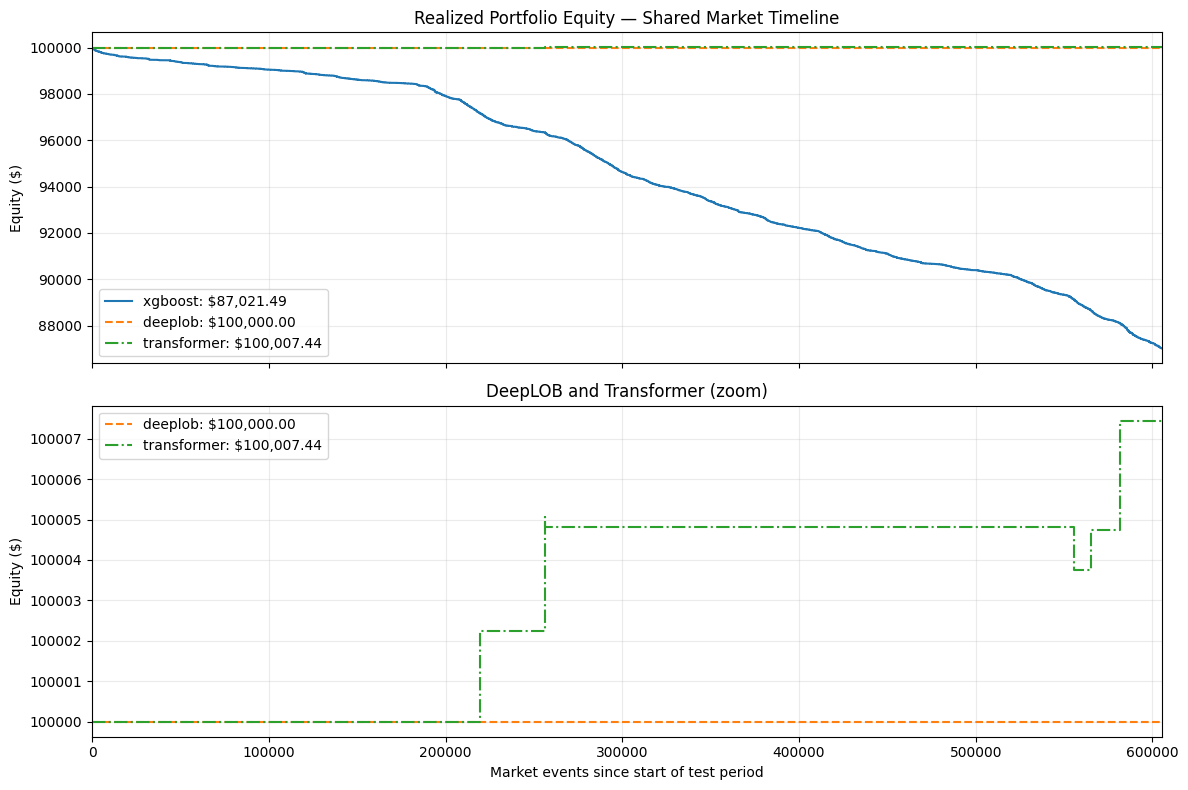

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

models = ["xgboost", "deeplob", "transformer"]
curves = {}

for model in models:
    path = OUTPUT_ROOT / model / "portfolio_backtest" / "equity_curve.csv"
    curves[model] = (
        pd.read_csv(path)
        .set_index("event_index")["equity"]
        .sort_index()
    )

start = int(splits["test"].min())
end = max(
    int(splits["test"].max()),
    max(int(s.index.max()) for s in curves.values()),
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, (model, s) in enumerate(curves.items()):
    # Extend each portfolio across the same period.
    s = (
        s.reindex(s.index.union([start, end]))
        .sort_index()
        .ffill()
        .fillna(float(s.iloc[0]))
    )

    # The zoom panel contains only DeepLOB and Transformer.
    panels = axes if model != "xgboost" else axes[:1]
    for ax in panels:
        ax.step(
            s.index - start, s.values, where="post",
            color=f"C{i}", linestyle=["-", "--", "-."][i],
            label=f"{model}: ${s.iloc[-1]:,.2f}",
        )

axes[0].set_title("Realized Portfolio Equity — Shared Market Timeline")
axes[1].set_title("DeepLOB and Transformer (zoom)")
axes[1].set_xlabel("Market events since start of test period")

for ax in axes:
    ax.set_ylabel("Equity ($)")
    ax.set_xlim(0, end - start)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()
fig.savefig(
    FINAL_DIR / "portfolio_equity_shared_timeline.png",
    dpi=160, bbox_inches="tight",
)
plt.show()

## Package Kaggle outputs

In [13]:
import tarfile
import shutil

bundle = Path("/kaggle/working/deeplob_results")

if bundle.exists():
    shutil.rmtree(bundle)

bundle.mkdir(parents=True, exist_ok=True)

shutil.copytree(OUTPUT_ROOT, bundle / "btc_h40_cost")
shutil.copytree(FINAL_DIR, bundle / "final")

archive = Path("/kaggle/working/deeplob_results.tar.gz")

if archive.exists():
    archive.unlink()

with tarfile.open(archive, "w:gz") as tf:
    tf.add(bundle, arcname="deeplob_results")

print("Results archive:", archive)
print(f"Size: {archive.stat().st_size / 1e6:.1f} MB")
print("Save a Kaggle notebook version to preserve /kaggle/working outputs.")

Results archive: /kaggle/working/deeplob_results.tar.gz
Size: 25.1 MB
Save a Kaggle notebook version to preserve /kaggle/working outputs.
